In [1]:
import numpy as np
import matplotlib.pyplot as plt
import stable_baselines3

import calmly

# `calmly`: Cavity alignment with ML

## Appendix: `calmly.simulator`
- Simulates the process of aligning any optical cavity to a laser beam with two steering mirrors
- Works with models of arbitrary cavities created in [Finesse 3](https://finesse.ifosim.org/docs/latest/).
- Produces cavity scans that can be used to teach the reinforcement learning agents
- `Piezomotor` class for simulating the action of piezoelectric stick-slip motors

### Example: a two-mirror cavity
![](./cavalign_example_schematic.png)

We are going to use a special-case constructor for `CavityAlignment`, `calmly.CavityAlignment.two_mirror_cavity()`, which automatically creates and stores the Finesse model of a two-mirror (Fabry-Perot) cavity from the given parameters. It is possible to use the general constructor `calmly.CavityAlignment()` instead in order to simulate cavities represented by arbitrary custom Finesse models. 

In [9]:
cav_align = calmly.CavityAlignment.two_mirror_cavity(
    Lcav = 1.0,          # Cavity length IC<-->OC
    Rc = (np.inf, 3.0),  # RoCs of IC and OC
    Refl = (0.95, 0.95), # Reflection off IC and OC
    Loss = (0.0, 0.0),   # Internal loss in IC and OC
    StSp = (1.0, 2.0)    # Distances SM1<-->SM2 and SM2<-->IC
)
cav_align.set_maxtem(11) # Number of TEM modes to include in the simulation

#### Misaligning the input coupler by 300 urad and producing a cavity scan:
We change the yaw angle of the input cavity mirror IC by $\alpha=3\times 10^{-4}$ rad and take a cavity scan by changing the laser frequency and looking at the DC readout of the photodetector in transmission. Note that by default the `.cavity_scan()` method changes the frequency over 2.1 free spectral ranges (FSRs) of the optical cavity. This can be changed by passing a `scan_range_in_fsrs` parameter to `.cavity_scan()`. See the help for this method for more details.

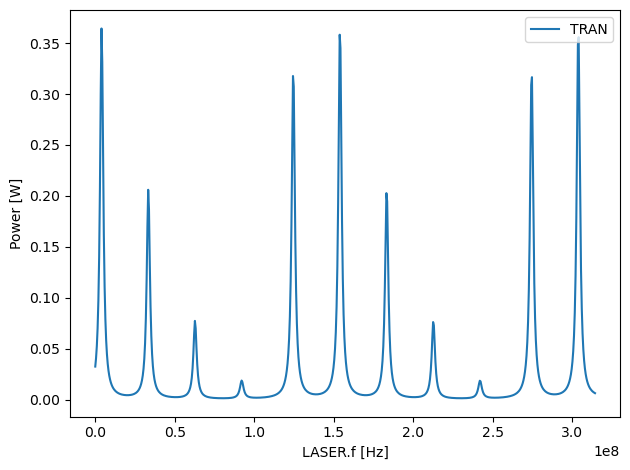

In [10]:
cav_align.m.IC.xbeta = 3e-4
cav_align.cavity_scan(ppbw_resolution = 5, plot=True);

#### Compensating for the IC misalignment by turning steering mirror 2 by 150 urad:
Since SM2 happens to be at the centre of curvature of the curved cavity mirror OC, the misalignment we created by turning the plane input cavity mirror IC by $\alpha=3\times 10^{-4}$ rad can be compensated for by turning SM2 in the same direction by $\alpha/2$. When we do that, indeed only the TEM00 peaks remain visible in the cavity scan:

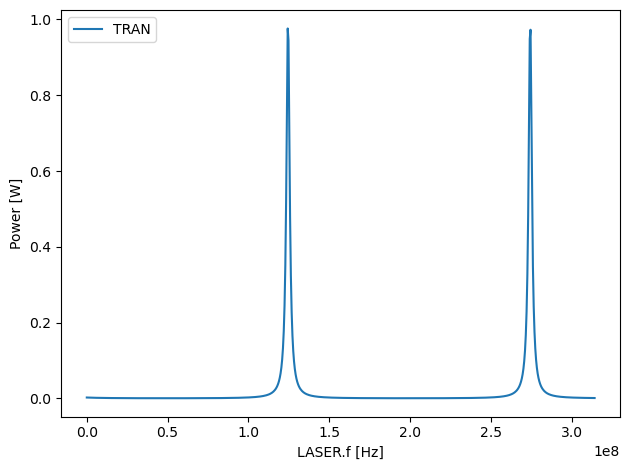

In [4]:
cav_align.sm2.xbeta = 1.5e-4
cav_align.cavity_scan(ppbw_resolution = 5, plot=True);

### Convergence testing
Including a sufficient number of TEM modes is crucial for the simulation to generate realistic cavity scans. There should be enough modes to adequately describe the shifted and misaligned beams in a fixed TEM mode basis. The convergence breaks down quickly when the misalignment angles are increased.

The `.get_convergence_curves()` method misaligns a selected optical component in the model to aid with selecting the right amount of TEM modes. Note that the Finesse parameter `maxtem` selects the highest _order_ of TEM modes to be included, not the total number of modes (i.e. `maxtem=19` will include 210 modes in total). Then the selected detectors are plotted, e.g. in our example the first plot is the sum of reflected and transmitted power by the cavity. When this value is not close to 1, this means that the power is lost into unaccounted modes. The plots show that the required amount of modes grows quickly with increasing angles. Note, however, that the signal in transmission near the resonance requires less modes to converge, since the calculation is done in the cavity basis and the cavity is assumed to belocked to the TEM00 mode, thus filtering the others.

maxtem=1 calculation finished
maxtem=3 calculation finished
maxtem=7 calculation finished
maxtem=11 calculation finished
maxtem=15 calculation finished
maxtem=19 calculation finished


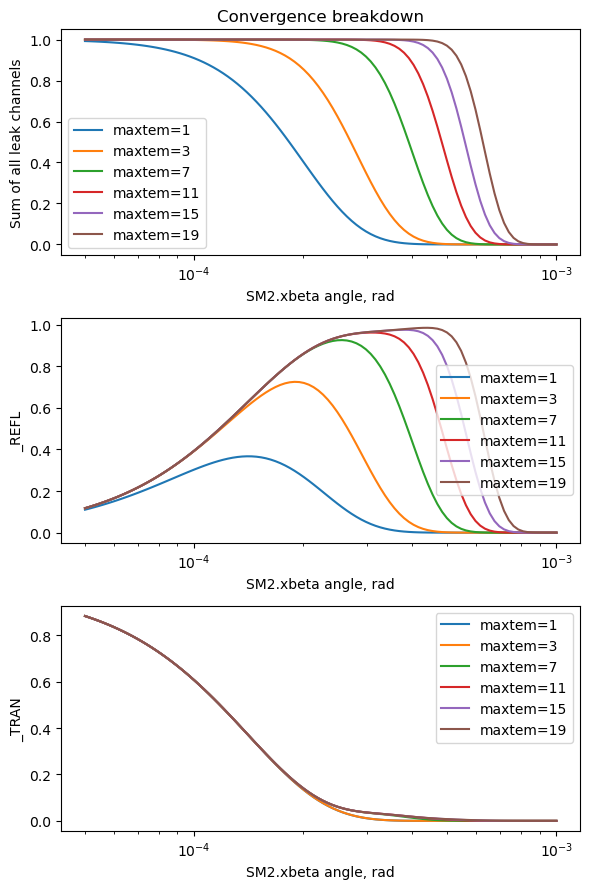

In [5]:
cav_align.m.IC.xbeta = 0
cav_align.sm2.xbeta = 0

cav_align.get_convergence_curves(axis = cav_align.sm2.xbeta,
                                 x = np.geomspace(5e-5,1e-3,100),
                                 maxtem_list = [1, 3, 7, 11, 15, 19],
                                 cavity_leak_channels = [cav_align.m.IC.p1.o, cav_align.m.OC.p2.o],
                                 leak_channel_names = ['_REFL', '_TRAN'],
                                 lock_to_mode=[0,0],
                                 plot = 'all',
                                 plot_logx = True
                                );

### Motors
The model can simulate the effect of piezoelectric stick-slip motors (e.g. the Picomotors) attached to the steering mirrors' pitch and yaw axes. Note that these motors typically have different calibration coefficients (in units of rad/count) for the positive and negative directions.

In [6]:
# attaching identical motors to all alignment degrees of freedom
cav_align.init_all_steering_motors(pos_coef=1.2e-6, neg_coef=0.9e-6, uncertainty=0.1)

Moving a motor forward and back by the same number of counts will not restore the corresponding alignment angle:

In [7]:
print(cav_align.dof_info(cav_align.sm2.xbeta))
print("Moving SM2.xbeta motor by +100 counts")
cav_align.move_steering_motor(cav_align.sm2.xbeta, 100)
print(cav_align.dof_info(cav_align.sm2.xbeta))
print("Moving SM2.xbeta motor by -100 counts")
cav_align.move_steering_motor(cav_align.sm2.xbeta, -100)
print(cav_align.dof_info(cav_align.sm2.xbeta))

SM2.xbeta = 0.0 radians, motor pos = 0
Moving SM2.xbeta motor by +100 counts
SM2.xbeta = 0.00010885342989521611 radians, motor pos = 100
Moving SM2.xbeta motor by -100 counts
SM2.xbeta = 3.4828153808866074e-06 radians, motor pos = 0


In [2]:
def cav_sim_factory(
    maxtem = 3,
    mis_angle_min=-2e-4,
    mis_angle_max=2e-4
):
    cav_sim = calmly.CavityAlignment.two_mirror_cavity(
        Lcav = 1.0,          # Cavity length IC<-->OC
        Rc = (np.inf, 3.0),  # RoCs of IC and OC
        Refl = (0.95, 0.95), # Reflection off IC and OC
        Loss = (0.0, 0.0),   # Internal loss in IC and OC
        StSp = (2.0, 1.0)    # Distances SM1<-->SM2 and SM2<-->IC
    )
    cav_sim.set_maxtem(maxtem)
    
    cav_sim.add_misalignment_axes([
        cav_sim.m.IC.xbeta,
        cav_sim.m.IC.ybeta,
        cav_sim.m.OC.xbeta,
        cav_sim.m.OC.ybeta
    ], [mis_angle_min]*4, [mis_angle_max]*4)
    
    cav_sim.init_all_steering_motors(pos_coef=1.2e-6, neg_coef=1.0e-6, uncertainty=0, low_limit=-1000, high_limit=1000)
    return cav_sim

def scan_processor_factory(signal_ref=None):
    if signal_ref is None:
        signal_ref = cav_sim_factory().signal_ref
    return calmly.CavityScanPreProcess(signal_reference_level = signal_ref)

In [3]:
model = stable_baselines3.PPO.load("ppo_training")

model_to_test = model

test_env = calmly.get_env_factory(cav_sim_factory=cav_sim_factory, scan_processor_factory=scan_processor_factory, monitor=False, training=False, mis_angle_min=-2e-4, mis_angle_max=2e-4)()

obs, _ = test_env.reset()
terminated = False
truncated=False
episode_reward = 0
count=0
rewards =[]
action_list = []
dominance_list = []
r_dominance_list = []
delta_dominance_list = []

reward_components = {}
for rc in test_env.reward_component_keys:
    reward_components[rc] = []
    


while not (terminated or truncated):
    # obs = {key: value.astype("float32") for key, value in obs.items()}
    action, _ = model_to_test.predict(obs, deterministic=True)  # Use deterministic actions for testing
    obs, reward, terminated, truncated, info = test_env.step(int(action))  # Step in the environment
    episode_reward += reward
    count += 1
    # print(f"Step: {action}, Reward: {reward}")
    if (count%50)==0:
        print('step:', test_env._steps_taken, '\trew:', reward, '\tdom:', test_env._cur_dominance, \
      '\tddom:', test_env._cur_delta_dominance, '\tNpeaks:', info['Npeaks_found'])
    rewards.append(reward)
    action_list.append(int(action))
    dominance_list.append(test_env._cur_dominance)
    r_dominance_list.append(test_env._cur_r_dominance)
    delta_dominance_list.append(test_env._cur_delta_dominance)

    
    for rc in test_env.reward_component_keys:
        reward_components[rc].append(info.get('reward/'+rc, 0))

print(f"Total Episode Reward: {episode_reward}")
print("Truncated:", truncated, ";   Terminated:", terminated)

print("Cavity optics misalignment angles:")
print("IC yaw: ", test_env.cav_sim.m.IC.xbeta.value)
print("IC pitch: ", test_env.cav_sim.m.IC.ybeta.value)
print("OC yaw: ", test_env.cav_sim.m.OC.xbeta.value)
print("OC pitch: ", test_env.cav_sim.m.OC.ybeta.value)



step: 50 	rew: 4.3313266416812795 	dom: 0.18490332279269284 	ddom: 0.001870493224422204 	Npeaks: 1
step: 100 	rew: 0.10298049042455348 	dom: 0.19344918164209332 	ddom: -0.0004381649111773467 	Npeaks: 1
Total Episode Reward: 625.0055846466041
Truncated: False ;   Terminated: True
Cavity optics misalignment angles:
IC yaw:  8.203525344235629e-05
IC pitch:  -0.0001646128763040543
OC yaw:  -9.631099860350766e-05
OC pitch:  8.087943373793029e-05


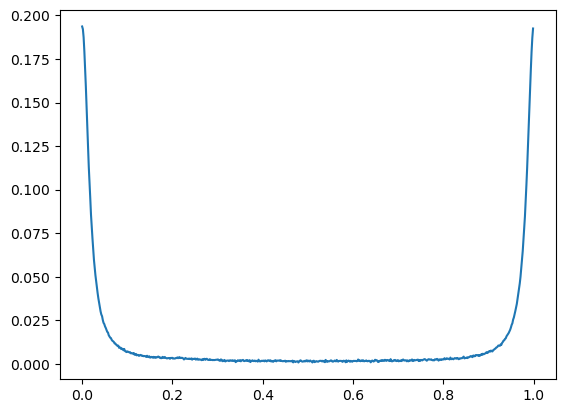

In [4]:
plt.figure()
plt.plot(info['x1'],info['y1'])
plt.show()

Total steps: 113


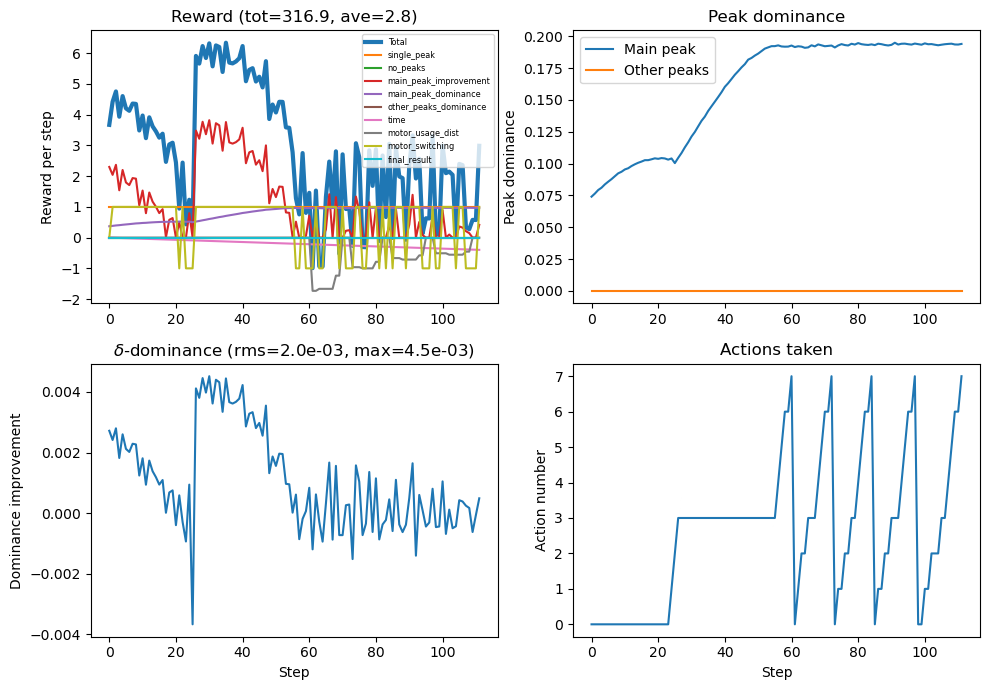

In [5]:
steps = np.arange(len(rewards))

print("Total steps:", len(steps))

step_lowlim  = None
step_highlim =  -1

if step_lowlim is None:
    step_lowlim = 0
if step_highlim is None:
    step_highlim = None

ddom_list_nonone = [ddom for ddom in delta_dominance_list[step_lowlim:step_highlim] if ddom is not None]
if len(ddom_list_nonone) != 0:
    ddom_rms = (sum([ddom**2 for ddom in ddom_list_nonone])/len(ddom_list_nonone))**0.5
    ddom_max = max([np.abs(ddom) for ddom in ddom_list_nonone])
else:
    ddom_rms=0
    ddom_max=0


plt.figure(figsize=(10,7))
plt.subplot(221)
plt.plot(steps[step_lowlim:step_highlim], rewards[step_lowlim:step_highlim], lw=3, label='Total')
for rc in test_env.reward_component_keys:
    if rc=='total':
        continue
    plt.plot(steps[step_lowlim:step_highlim], reward_components[rc][step_lowlim:step_highlim], label=rc)
    
plt.legend(fontsize='xx-small')
plt.title(f'Reward (tot={sum(rewards[step_lowlim:step_highlim]):.1f}, ave={sum(rewards[step_lowlim:step_highlim])/len(rewards[step_lowlim:step_highlim]):.1f})')
plt.ylabel('Reward per step')
axc1 = plt.gca()
plt.subplot(222)
plt.plot(steps[step_lowlim:step_highlim], dominance_list[step_lowlim:step_highlim], label='Main peak')
plt.plot(steps[step_lowlim:step_highlim], r_dominance_list[step_lowlim:step_highlim], label='Other peaks')
plt.legend()
plt.title(f"Peak dominance")
plt.ylabel("Peak dominance")
axc2 = plt.gca()
plt.subplot(223, sharex = axc1)
plt.plot(steps[step_lowlim:step_highlim], delta_dominance_list[step_lowlim:step_highlim])
plt.title(f'$\\delta$-dominance (rms={ddom_rms:.1e}, max={ddom_max:.1e})')
plt.ylabel('Dominance improvement')
plt.xlabel('Step')
plt.subplot(224, sharex = axc2)
plt.plot(steps[step_lowlim:step_highlim], action_list[step_lowlim:step_highlim])
plt.title('Actions taken')
plt.ylabel('Action number')
plt.xlabel('Step')

plt.tight_layout()
plt.show()